<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day13-discussion-3.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 13, Segment 3 discussion — How many reverse steps does generation actually need?

The book page uses T=100 reverse-diffusion steps. Real production models often use far
fewer at generation time (this is exactly flow matching's selling point). Trained once
at T=100, does *sampling* with fewer steps at generation time still work reasonably, or
does quality collapse?

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_ring_data(n):
    theta = torch.rand(n) * 2 * np.pi
    r = 3 + 0.3 * torch.randn(n)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)

X2d = make_ring_data(4000).to(device)

T2 = 100
betas2 = torch.linspace(1e-4, 0.05, T2).to(device)
alphas2 = 1 - betas2
alpha_bars2 = torch.cumprod(alphas2, dim=0)

class DenoiseNet(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.time_embed = nn.Embedding(T2, hidden)
        self.net = nn.Sequential(nn.Linear(dim + hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, dim))

    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_embed(t)], dim=1))

dnet = DenoiseNet().to(device)
opt = torch.optim.Adam(dnet.parameters(), lr=1e-3)
for step in range(3000):
    idx = torch.randint(0, X2d.shape[0], (256,), device=device)
    x0 = X2d[idx]
    t = torch.randint(0, T2, (256,), device=device)
    noise = torch.randn_like(x0)
    ab = alpha_bars2[t].unsqueeze(1)
    xt = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    pred = dnet(xt, t)
    loss = ((pred - noise) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
print('trained once at T=100, final loss:', loss.item())

trained once at T=100, final loss: 0.6479235887527466


## Sample using only every k-th step of the trained schedule (a crude DDIM-style skip)

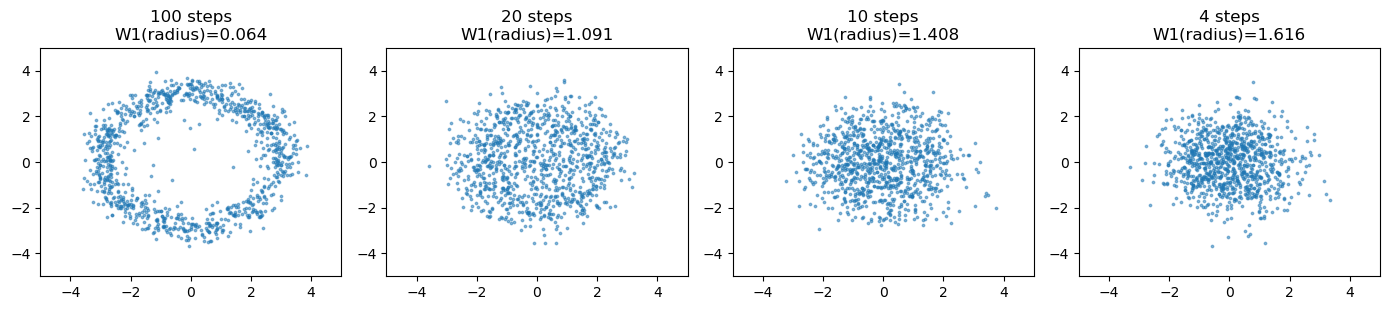

In [2]:
@torch.no_grad()
def reverse_sample_skip(n, stride):
    """Use only every `stride`-th timestep of the trained 100-step schedule."""
    steps = list(reversed(range(0, T2, stride)))
    x = torch.randn(n, 2, device=device)
    for t in steps:
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        pred_noise = dnet(x, tt)
        alpha, alpha_bar, beta = alphas2[t], alpha_bars2[t], betas2[t]
        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise) + torch.sqrt(beta) * noise
    return x, len(steps)

real = X2d.cpu().numpy()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, stride in zip(axes, [1, 5, 10, 25]):
    gen, n_steps = reverse_sample_skip(1000, stride)
    gen = gen.cpu().numpy()
    r_gen = np.sqrt(gen[:, 0]**2 + gen[:, 1]**2)
    r_real = np.sqrt(real[:, 0]**2 + real[:, 1]**2)
    w1 = wasserstein_distance(r_real, r_gen)
    ax.scatter(gen[:, 0], gen[:, 1], s=3, alpha=0.5)
    ax.set_title(f'{n_steps} steps\nW1(radius)={w1:.3f}')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
plt.tight_layout()
plt.savefig('day13-discussion3-steps.png', dpi=110)
plt.show()

## Takeaway

The Wasserstein distance between the real and generated radius distributions (printed
above each panel) is the actual, measured answer to "how much does quality degrade" —
read it directly rather than eyeballing the scatter plots alone. This step-count/quality
tradeoff, measured here for a model *trained* at fixed T=100 and then sampled with fewer
steps, is exactly the practical motivation the book page's flow-matching section gives
for why flow matching (which is designed for few-step sampling from the start) is
attractive in practice.